# Проект

Представьте, что вы работаете в крупном дейтинговом приложении.

Помимо базовых функций, в приложении также имеется премиум-подписка, которая дает доступ к ряду важных дополнительных возможностей. Был проведен A/B тест, в рамках которого для новых пользователей из нескольких стран была изменена стоимость премиум-подписки* при покупке через две новые платежные системы. При этом стоимость пробного периода оставалась прежней.

Проверьте:

1. Был ли эксперимент успешен в целом.
2. Проанализируйте, имеет ли нововведение смысл среди каких-либо конкретных групп пользователей.

*Деньги за подписку списываются ежемесячно до тех пор, пока пользователь её не отменит.

## Данные
Всего есть три группы: тестовая (*test*), контрольная 1 (*control_1*) и контрольная 2 (*control_2*). Для каждой из них:

users_*.csv – информация о пользователях:

* **uid** – идентификатор пользователя
* **age** – возраст
* **attraction_coeff** – коэффициент привлекательности
* **coins** – число монеток (внутренняя валюта)
* **country** – страна  
* **visit_days** – в какие дни после регистрации пользователь посещал приложение (напр. в 1, затем в 7)
* **gender** – пол
* **age_filter_start**  – фильтр поиска, мин. значение 
* **age_filter_end**  – фильтр поиска, макс. значение 
* **views_count** – число полученных оценок 
* **was_premium** – был ли когда-либо премиум (либо пробный период премиум-статуса, либо купленный за деньги)
* **is_premium** –  является ли премиум
* **total_revenue** – нормированная выручка 

transactions_*.csv – информация о платежах пользователей:

* **uid** – идентификатор пользователя
* **country** – страна
* **joined_at** – дата и время регистрации
* **paid_at** – дата и время покупки
* **revenue** – нормированная выручка
* **payment_id** – идентификатор платежа
* **from_page** – откуда пользователь перешел на страницу оплаты
* **product_type** – тип продукта (trial_premium – пробная премиум-подписка, premium_no_trial – премиум-подписка без пробной, * * **coins** – подписка за внутреннюю валюту, other_type – другое)



Импортириуем необходимые библиотеки

In [1]:
import requests
import pandas as pd
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from tqdm.auto import tqdm

%matplotlib inline
plt.style.use('ggplot')

Загружаем наши данные

In [2]:
def get_data(public_key):
    base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'

    # Получаем загрузочную ссылку
    final_url = base_url + 'public_key=' + public_key
    response = requests.get(final_url)
    download_url = response.json()['href']
    req = requests.get(download_url)
    data = req.content

    df = pd.read_csv(BytesIO(data), sep=';')
    return df

In [3]:
users_test = 'https://disk.yandex.ru/d/4XXIME4osGrMRA'
users_control_1 = 'https://disk.yandex.ru/d/yJFydMNNGkEKfg'
users_control_2 = 'https://disk.yandex.ru/d/br6KkQupzzTGoQ'
transactions_test = 'https://disk.yandex.ru/d/gvCWpZ55ODzs2g'
transactions_control_1 = 'https://disk.yandex.ru/d/VY5W0keMX5TZBQ'
transactions_control_2 = 'https://disk.yandex.ru/d/th5GL0mGOc-qzg'
u_test = get_data(users_test)
u_1 = get_data(users_control_1)
u_2 = get_data(users_control_2)
t_test = get_data(transactions_test)
t_1 = get_data(transactions_control_1)
t_2 = get_data(transactions_control_2)

# Предобработка данных


Посмотрим на наши данные:

In [4]:
print(u_test.info(), u_1.info(), u_2.info(), t_test.info(), t_1.info(), t_2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4308 entries, 0 to 4307
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               4308 non-null   int64  
 1   age               4308 non-null   int64  
 2   attraction_coeff  4308 non-null   int64  
 3   coins             49 non-null     float64
 4   country           4308 non-null   object 
 5   visit_days        2978 non-null   object 
 6   gender            4308 non-null   int64  
 7   age_filter_start  4308 non-null   int64  
 8   age_filter_end    4308 non-null   int64  
 9   views_count       4308 non-null   int64  
 10  was_premium       408 non-null    float64
 11  is_premium        157 non-null    float64
 12  total_revenue     4308 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 437.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 13 columns):
 #   Column      

Видим множество пропущенных значений. В транзакциях первой контрольной группы присутствуют лишние пустые строки. Удалим их, вместо остальных пропусков вставим 0.

In [5]:
t_1 = t_1.dropna()

In [6]:
u_test = u_test.fillna(0)
u_1 = u_1.fillna(0)
u_2 = u_2.fillna(0)

Изменим типы данных на более подходящие.

In [7]:
t_1[['uid', 'revenue', 'payment_id']] = t_1[['uid', 'revenue', 'payment_id']].astype(int)
u_test[['is_premium', 'was_premium']] = u_test[['is_premium', 'was_premium']].astype(int)
u_1[['is_premium', 'was_premium']] = u_1[['is_premium', 'was_premium']].astype(int)
u_2[['is_premium', 'was_premium']] = u_2[['is_premium', 'was_premium']].astype(int)
t_test[['joined_at', 'paid_at']] = t_test[['joined_at', 'paid_at']].apply(pd.to_datetime)
t_1[['joined_at', 'paid_at']] = t_1[['joined_at', 'paid_at']].apply(pd.to_datetime)
t_2[['joined_at', 'paid_at']] = t_2[['joined_at', 'paid_at']].apply(pd.to_datetime)

Сравним группы между собой по временным отрезкам.

In [8]:
print(t_test['joined_at'].min(), t_test['joined_at'].max())
print(t_1['joined_at'].min(), t_1['joined_at'].max())
print(t_2['joined_at'].min(), t_2['joined_at'].max())

2017-01-11 03:07:00 2017-10-31 23:40:00
2015-01-19 11:49:00 2017-10-31 22:17:00
2017-01-11 08:36:00 2017-10-31 17:43:00


В первой контрольной группе присутствуют странные транзакции за 2015 год. Взгляним на них получше:

In [9]:
t_1.query('joined_at < "2017-01-11"')

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
65,960936960,Russian Federation,2015-01-19 11:49:00,2016-12-14 17:30:00,26,0,refund_VP,other_type
101,960936960,Russian Federation,2015-01-19 11:49:00,2016-12-14 17:35:00,637,0,refung_AP,other_type
224,960936960,Russian Federation,2015-01-19 11:49:00,2016-12-14 16:16:00,143,0,refund_WP,other_type


In [10]:
u_1.query('uid == 960936960')

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
510,960936960,30,4,99958.0,Russian Federation,"1,2,3,4,7,8,9,10,11,14,15,16,17,18,21,22,23,24...",1,26,62,4262,1,1,26


Для чистоты эксперимента наши данные должны быть взяты за одинаковые временные отрезки, поэтому уберем данного юзера из наших датафреймов.

In [11]:
u_1 = u_1.loc[u_1['uid'] != 960936960].copy()
t_1 = t_1.loc[t_1['uid'] != 960936960].copy()

Посмотрим сходятся ли данные юзеров и их транзакций:

In [12]:
print(
    u_test.total_revenue.sum() == t_test.revenue.sum(),
    u_1.total_revenue.sum() == t_1.revenue.sum(),
    u_2.total_revenue.sum() == t_2.revenue.sum()
)

False False True


Данные не сходятся, взгляем подробнее:

In [13]:
revenue_test = t_test.groupby('uid').revenue.sum().reset_index()
u_test_r = u_test.merge(revenue_test, on='uid', how='left')
u_test_r[(u_test_r.total_revenue != u_test_r.revenue) & (u_test_r.revenue >0)]

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue,revenue
2070,892275462,31,310,0.0,France,"1,2,3,4,5,9,13,15,16",1,36,68,58,1,1,14885,58968.0


In [14]:
t_test.query('uid == 892275462')

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
64,892275462,France,2017-10-17 05:56:00,2017-02-11 18:24:00,44083,19,coins_popup,other_type
154,892275462,France,2017-10-17 05:56:00,2017-10-20 17:00:00,14885,68,super_popup,other_type


Видим что одна из транзакций не была учтена в таблице с юзерами. Изменим значение total_revenue для данного юзера.

In [15]:
u_test.loc[u_test['uid'] == 892275462, 'total_revenue'] = 58968
u_test.total_revenue.sum() == t_test.revenue.sum()

True

Проделаем ту же операцию с первой контрольной группой.

In [16]:
revenue_1= t_1.groupby('uid').revenue.sum().reset_index()
u_1_r = u_1.merge(revenue_1, on='uid', how='left')
u_1_r[(u_1_r.total_revenue != u_1_r.revenue) & (u_1_r.revenue >0)]

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue,revenue
3369,892355163,40,640,0.0,United States of America,"1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,1...",1,25,60,700,1,0,0,30264.0


In [17]:
t_1.query('uid == 892355163')

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
303,892355163,United States of America,2017-10-15 18:45:00,2017-10-16 09:52:00,30264,68,super_popup,other_type


In [18]:
u_1.loc[u_1['uid'] == 892355163, 'total_revenue'] = 30264
u_1.total_revenue.sum() == t_1.revenue.sum()

True

Посмотрим на наличие дубликатов.

In [19]:
print(u_test.duplicated().sum(),
      u_1.duplicated().sum(), 
      u_2.duplicated().sum(),
      t_test.duplicated().sum(),
      t_1.duplicated().sum(),
      t_2.duplicated().sum(), sep='\n')

0
0
0
7
21
5


In [20]:
t_2[t_2.duplicated()]

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
86,891862596,Italy,2017-10-26 01:40:00,2017-10-30 09:01:00,1261,19,empty_likes,coins
235,892064328,United States of America,2017-10-21 20:54:00,2017-10-22 01:30:00,6305,19,empty_likes,coins
241,892009254,Italy,2017-10-22 22:57:00,2017-10-23 00:06:00,2353,67,empty_likes,other_type
288,892062660,United States of America,2017-10-21 21:28:00,2017-10-31 00:53:00,1261,19,empty_likes,coins
321,892045743,Israel,2017-10-22 07:04:00,2017-10-23 20:17:00,1261,19,empty_likes,coins


Дубликаты присутствуют в датафреймах транзакций, однако т.к выручка юзеров и транзакций бьется между собой, скорее всего все в порядке. Возможно дубликаты возникают потому, что во времени транзакций не учтены секунды.



Мы очистили наши данные и привели их к единообразному виду. Можем двигаться далее

## A/A - тест

Перейдем к A/A-тесту. Будем оценивать качество работы системы сплитования путём проверки FPR (False Positive Rate) наших ключевых бизнес-метрик

За ключевые метрики возьмем ARPU и конверсию. Т.к эксперимент состоял в изменении стоимости премиум-подписки, то за конверсию будем считать покупку именно премиум-подписки без учета пробных подписок.

Для начала взглянем на распределение выручки по пользователям:

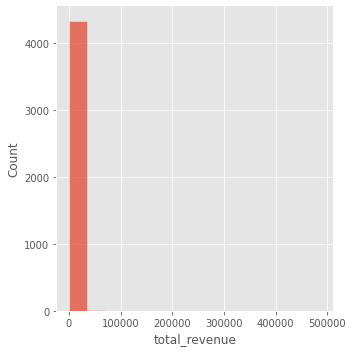

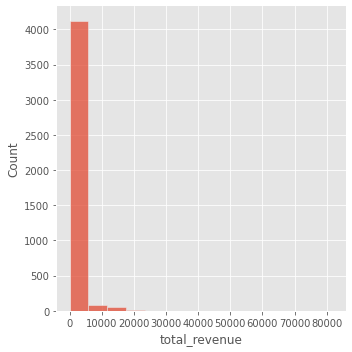

In [21]:
sns.displot(u_1.total_revenue)
sns.displot(u_2.total_revenue)

Как мы видим распределения очень искажены, ненормальны и имеют большой скос вправо из-за присутствия выбросов. Из-за этого t-test вряд ли подойдет в качестве статистического оценщика. Поэтому для сравнения наших контрольных групп воспользуемся непараметрическим методом Манна-Уитни.

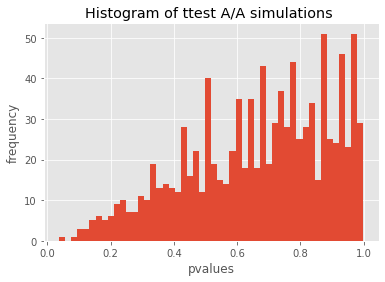

0.001

In [22]:
simulations = 1000
n_s = 3000
res = []


# Запуск симуляций A/A теста
for i in tqdm(range(simulations)):
    s1 = u_1.total_revenue.sample(n_s, replace = False)
    s2 = u_2.total_revenue.sample(n_s, replace = False)
    res.append(stats.mannwhitneyu(s1, s2)[1]) # сохраняем pvalue

plt.hist(res, bins = 50)
plt.xlabel('pvalues')
plt.ylabel('frequency')
plt.title("Histogram of ttest A/A simulations ")
plt.show()

sum(np.array(res) <0.05) / simulations

A/A-тест по ARPU прошел корректно. FPR < меньше заданного уровня 0.05.


Перейдем к конверсии

За конверсию мы берем покупки только обычной премиум-подписки. Чтобы посчитать такую конверсию нам необходимо слегка преобразовать данные. Добавим колонку, которая будет указывать оформил ли юзер премиум-подписку без учета триал-версии.

In [23]:
t_1['premium_no_trial'] = np.where(t_1['product_type'] == 'premium_no_trial', 1, 0)
t_11 = t_1.query('product_type == "premium_no_trial"').drop_duplicates(subset=['uid'])
u_1 = u_1.merge(t_11[['uid','premium_no_trial']], on='uid', how = 'left')
u_1 = u_1.fillna(0)
u_1['premium_no_trial'] = u_1['premium_no_trial'].astype(int)

t_2['premium_no_trial'] = np.where(t_2['product_type'] == 'premium_no_trial', 1, 0)
t_22 = t_2.query('product_type == "premium_no_trial"').drop_duplicates(subset=['uid'])
u_2 = u_2.merge(t_22[['uid','premium_no_trial']], on='uid', how = 'left')
u_2 = u_2.fillna(0)
u_2['premium_no_trial'] = u_2['premium_no_trial'].astype(int)

t_test['premium_no_trial'] = np.where(t_test['product_type'] == 'premium_no_trial', 1, 0)
t_tt = t_test.query('product_type == "premium_no_trial"').drop_duplicates(subset=['uid'])
u_test = u_test.merge(t_tt[['uid','premium_no_trial']], on='uid', how = 'left')
u_test = u_test.fillna(0)
u_test['premium_no_trial'] = u_test['premium_no_trial'].astype(int)

Конверсия является категориальная переменной - это значит, что мы можем использовать критерий хи-квадрат для проверки разницы конверсий между двумя контрольными группами.

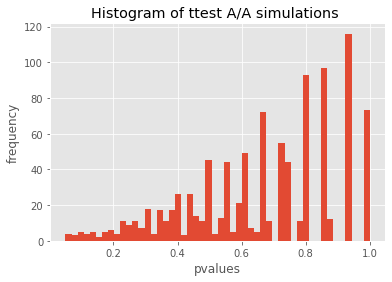

0.002

In [24]:
simulations = 1000
n_s = 3000
res = []


# Запуск симуляций A/A теста
for i in tqdm(range(simulations)):    
    s1 = u_1.premium_no_trial.sample(n_s, replace = False)
    s2 = u_2.premium_no_trial.sample(n_s, replace = False)
    a_premium = s1.sum()
    a_nopremium = s1.size - s1.sum()
    b_premium = s2.sum()
    b_nopremium = s2.size - s2.sum()
    T = np.array([[a_premium, a_nopremium], [b_premium, b_nopremium]])
    res.append(stats.chi2_contingency(T,correction=False)[1]) # сохраняем pvalue

plt.hist(res, bins = 50)
plt.xlabel('pvalues')
plt.ylabel('frequency')
plt.title("Histogram of ttest A/A simulations ")
plt.show()

sum(np.array(res) <0.05) / simulations

FPR < 0.05, все хорошо.

## Итоги A/A-теста:

* По нашим ключевым бизнес-метрикам сплит-система отработала хорошо. Между нашими контрольными группами нет статичестической разницы в ARPU и конверсии.

## A/B-тест для проверки успешности эксперимента

Определим ключевые метрики для проверки успешности эксперимента. Возьмем те же метрики, что и для A/A-теста: ARPU и конверсию в премиум-подписки.

Начнем с ARPU.

Взглянем на распределение выручки по юзерам.

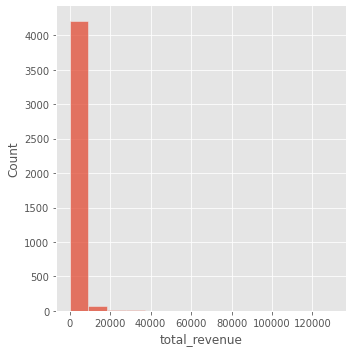

In [25]:
sns.displot(u_test.total_revenue)

Так же, как и в контрольных группах большинство юзеров находится в левой части графика, или точнее будет сказать у нуля, так как подавляющее большинство юзеров не сделало ни одной покупки.

Для простоты анализа преобразуем эти данные. Сначала объединим наши контрольные группы. Прибавим к выручке каждого юзера единицу и проведем логарифмирование, чтобы сгладить распределение и приблизить его к нормальному. 

In [26]:
u_control = pd.concat([u_1, u_2])

In [27]:
u_test['log_revenue'] = np.log(u_test.total_revenue+1)
u_control['log_revenue'] = np.log(u_control.total_revenue+1)

Проведем сравнение средних значений логарифмированной выручки между тестовой и контрольной группами. Для этого используем t-критерий Уэлча, чтобы исключить условие о разности дисперсий.

In [28]:
stats.ttest_ind(u_test.log_revenue, u_control.log_revenue, equal_var=False)

Ttest_indResult(statistic=-2.5169793011763764, pvalue=0.01185312647594008)

P-значение меньше стандартного уровня значимости в 0.05, а это значит, что средние в наших группах значимо различаются.
Однако что же именно это значит? Посмотрим на исходные средние:

In [29]:
print(u_test.total_revenue.mean(), u_control.total_revenue.mean(), sep='\n')

544.3131383472609
526.7863535975822


Мы видим, что среднее в тестовой группе больше, чем в контрольной группе. Стоит заметить, что само значение средних очень искажено присутствием большого количества нулевых значений.

Взглянем на общую конверсию. Для этого посчитаем число юзеров, совершивших хотя бы одну покупку, и разделим это число на общее количество юзеров.

In [30]:
print('Число юзеров без покупок в тестовой группе:', u_test[u_test.total_revenue ==0].shape[0])
print('Общее число юзеров в тестовой группе:', u_test.shape[0])
print('Конверсия:', round(u_test[u_test.total_revenue >0].shape[0]/u_test.shape[0]*100,1),'%')
print('Число юзеров без покупок в контрольной группе:', u_control[u_control.total_revenue ==0].shape[0])
print('Общее число юзеров в контрольной группе:', u_control.shape[0])
print('Конверсия:', round(u_control[u_control.total_revenue >0].shape[0]/u_control.shape[0]*100,1),'%')


Число юзеров без покупок в тестовой группе: 4162
Общее число юзеров в тестовой группе: 4308
Конверсия: 3.4 %
Число юзеров без покупок в контрольной группе: 8224
Общее число юзеров в контрольной группе: 8603
Конверсия: 4.4 %


In [31]:
print((u_test[u_test.total_revenue >0].shape[0]/u_test.shape[0])*u_test.total_revenue.mean(), 
      (u_control[u_control.total_revenue >0].shape[0]/u_control.shape[0])*u_control.total_revenue.mean())                                  

18.44700979542713 23.207256539984154


Посчитав матожидание выручки, мы можем увидеть, что матожидание для тестовой группы меньше, чем для контрольной группы, несмотря на то, что ARPU для тестовой группы было выше. Все из-за того, что конверсия в тестовой группе значительно меньше, чем в контрольной группе.

In [32]:
print(u_test.log_revenue.mean(), u_control.log_revenue.mean(), sep='\n')

0.3153806788752927
0.39757506306745943


Посмотрев на средние логарифмированных значений, мы также увидим, что среднее тестовой группы меньше, чем средние контрольной группы.

**Подытожим**: t-тест показал статистические различия между выручкой в тестовой и контрольной группе. Однако, это отрицательные, а не положительные различия, а это значит, что наш эксперимент отразился негативно на ARPU и будущей выручке.

Обратимся ко второй выбранной нами метрике: конверсии премиум-подписок. Для подсчета разниц между конверсиями воспользуемся хи-квадратом.

In [33]:
s1 = u_test.premium_no_trial
s2 = u_control.premium_no_trial
a_premium = s1.sum()
a_nopremium = s1.size - s1.sum()
b_premium = s2.sum()
b_nopremium = s2.size - s2.sum()
T = np.array([[a_premium, a_nopremium], [b_premium, b_nopremium]])
chi2, p, dof, expected = stats.chi2_contingency(T,correction=False)
p

0.003329986397413256

P-значение < нашего уровня значимости, что говорит о значимых различиях. Теперь расчитаем конверсию:

In [34]:
a_premium = a_premium / (a_premium + a_nopremium)
b_premium = b_premium / (b_premium + b_nopremium)
print('Конверсия в тестовой группе:', round(a_premium, 3), ', конверсия в контрольной группе:', round(b_premium, 3))

Конверсия в тестовой группе: 0.016 , конверсия в контрольной группе: 0.023


Мы видим, что конверсия значимо снизилась.

## Итоги A/B - теста

Мы провели A/B-тестирование для сравнение двух ключевых метрик после проведения эксперимента: ARPU и конверсии в премиум-подписку. Хоть статистические критерии и показали значимые различия между тестовой и контрольной группами, мы видим, что это негативные различия: ARPU не вырос настолько, чтобы компенсировать падение конверсии, конверсия в премиум-подписки также упала. Эксперимент можно признать неудачным.


Попробуем проанализировать имеет ли смысл нововведение среди каких-либо конкретных групп пользователей.

Возьмем гендер. Для сравнения будем использовать критерий Уэлша.

In [35]:
a4 = u_test[u_test.gender == 0].log_revenue
a5 = u_control[u_control.gender == 0].log_revenue
stats.ttest_ind(a4,a5, equal_var=False)

Ttest_indResult(statistic=-1.611486476012376, pvalue=0.1076357088685938)

In [36]:
a4 = u_test[u_test.gender == 1].log_revenue
a5 = u_control[u_control.gender == 1].log_revenue
stats.ttest_ind(a4,a5, equal_var=False)

Ttest_indResult(statistic=-2.294309397220904, pvalue=0.021796014824814476)

In [37]:
print(u_test[u_test.gender == 1].log_revenue.mean(), 
      u_control[u_control.gender == 1].log_revenue.mean())

0.32626319794597464 0.403977860572328


Для гендера 0 - нет статистических различий, для гендера 1 - есть различия между тестовой и контрольной группой, однако если мы вновь посмотрим на логарифмированные средние значения, мы увидим, что значения тестовой группы меньше, чем в контрольной группе.

Так как число конверсий в премиум-подписку для гендера 0 равно нулю в тестовой группе, анализ конверсии в гендерных группах не имеет смысла.

## Итоги эксперимента

По итогам повторного A/B тестирования можно признать эксперимент **неудачным**: конверсия значительно упала, а номинальный ARPU хоть и вырос, но при этом матожидание выручки и логарифмированные значения ARPU у тестовой группы оказались наименьшими. Все это в будущем приведет к уменьшению выручки.